In [22]:
import numpy as np
from numpy.linalg import eigh
from scipy.linalg import eigh, expm, svd
import sys
import os
import warnings
warnings.filterwarnings('ignore', category=UserWarning, append = True)


import tenpy
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg, tebd
from tenpy.networks.mpo import MPO
from tenpy_toycodes.a_mps import SimpleMPS, init_FM_MPS, init_Neel_MPS
from tenpy_toycodes.b_model import TFIModel
from tenpy_toycodes.d_dmrg import SimpleDMRGEngine, SimpleHeff2, DMRG_tf_ising_finite
from tenpy_toycodes.c_tebd import TEBD_tf_ising_finite
from tenpy_toycodes.tfi_exact import finite_gs_energy

import tenpy.linalg.np_conserved as npc
from tenpy.models.tf_ising import TFIChain

import time
import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

The bellow is a class constructed for the TFIM which is featured on the TeNPy website

In [ ]:
def QFI(psi, op):
    """
    Calculate the Quantum Fisher Information (QFI) for a given state and operator.
    
    Parameters:
    psi : MPS
        The matrix product state representing the quantum state.
    op : str
        The operator for which to calculate the QFI ('Sigmax' or 'Sigmaz').
        
    Returns:
    float
        The calculated QFI value.
    """
    # Calculate the expectation value of the operator
    expe = np.mean(psi.expectation_value(op))
    
    # Calculate the correlation function
    corr_q2 = psi.correlation_function(op, op, sites1=None, sites2=None)
    
    # Calculate the expectation value of the squared operator
    expectation_q2 = np.mean(corr_q2)
    
    # Calculate QFI using the formula: QFI = 4 * (expectation_q2 - expe^2)
    qfi = 4 * (expectation_q2 - expe**2)
    
    return qfi

def build_Q_MPO(model,  op = 'Sigmax'):
    """
    builds an MPO corresponding to Q = 1/L sum_i op_i
    """
    L = model.lat.N_cells
    Id = model.lat.unit_cell[0].get_op("Id")

    Q = model.lat.unit_cell[0].get_op(op)
        
    W = []
    for i in range(L):
        Wi = np.empty((2, 2), dtype=object)

        Wi[0, 0] = Id
        Wi[1, 1] = Id

        Wi[0, 1] = Q / L
        Wi[1, 0] = None

        W.append(Wi)

    return MPO.from_grids(model.lat.mps_sites(), W, IdL=0, IdR=1)

def calculate_QtQ(op, model_params, model_type = "Kondo",  dmrg_tebd_params = {} ):
    """ Calculates 1/2 < psi | {Q(t), Q} | psi > 
        for psi the ground state of model """

    if model_type == "Ising":
        M = TFIChain(model_params)
    else: 
        raise ValueError("Model type not configured yet")

    #DMRG engine
    psi = MPS.from_lat_product_state(M.lat, [['up']])
    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_tebd_params)
    E, psi = eng.run()
    
    # apply phi = Q |psi > Must be careful here because some processes
    # in MPS and MPO by default normalize the output wavefunction
    phi = psi.copy()
    op_MPO = build_Q_MPO(M , op)
    op_MPO.apply(phi, options={'compression_method' : 'SVD'})
    
    # TEBD engine
    phi_t = phi.copy()
    times = []
    expec_U = []  # 1/2 <psi | {Q(t), Q} | psi > = Re[< phi | U | phi > exp()]
    engine = tebd.TEBDEngine(phi_t, M, dmrg_tebd_params)

    
    for step in range(dmrg_tebd_params.get('N_steps', 10)):
        engine.run()
        t = engine.evolved_time
        times.append(t)
        expec_U.append(phi.overlap(phi_t))

        
    
    return phi.overlap(phi_t)



In [24]:
extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'dt': 0.05,'N_steps': 20,
        'order': 2
}

print(calculate_QtQ('Sigmax', model_params, model_type = "Ising", dmrg_tebd_params = extra_params))

(np.complex128(0.645263948510798+0.7639597044288026j), np.complex128(0.6451528634692831+0.7640535208723173j))


In [5]:
model_params = {
    'J': .1 , 'g': 1,  # critical
    'L': 6,
    'bc_MPS': 'finite',
    'conserve' : None
}

M = TFIChain(model_params)
psi = MPS.from_lat_product_state(M.lat, [['up']])
dmrg_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True
}
eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_params)
E, psi = eng.run() # the main work; modifies psi in place

M.lat.N_cells

6

In [4]:
L = 12
psi_FM = init_FM_MPS(L=L, d=2, bc='finite')
print(psi_FM)
SigmaZ = np.diag([1., -1.])
print(psi_FM.site_expectation_value(SigmaZ))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [64]:
L = 22
chi_max = 15
model = TFIModel(L=L, J=2.6, g=1, bc='finite')

psi = init_FM_MPS(model.L, 2, model.bc)
eng = SimpleDMRGEngine(psi, model, chi_max=chi_max, eps=1.e-10)
for i in range(20):
    E_dmrg = eng.sweep()
    E = np.sum(psi.bond_expectation_value(model.H_bonds))
    #print("sweep {i:2d}: E = {E:.13f}".format(i=i + 1, E=E))
print("final bond dimensions: ", psi.get_chi())
mag_x = np.mean(psi.site_expectation_value(model.sigmax))
mag_z = np.mean(psi.site_expectation_value(model.sigmaz))
print("magnetization in X = {mag_x:.5f}".format(mag_x=mag_x))
print("magnetization in Z = {mag_z:.5f}".format(mag_z=mag_z))
if model.L <= 16:
    E_exact = finite_gs_energy(L=model.L, J=model.J, g=model.g)
    print("err in energy = {err:.3e}".format(err=E - E_exact))

final bond dimensions:  [2, 4, 8, 12, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 12, 8, 4, 2]
magnetization in X = 0.21427
magnetization in Z = -0.00001


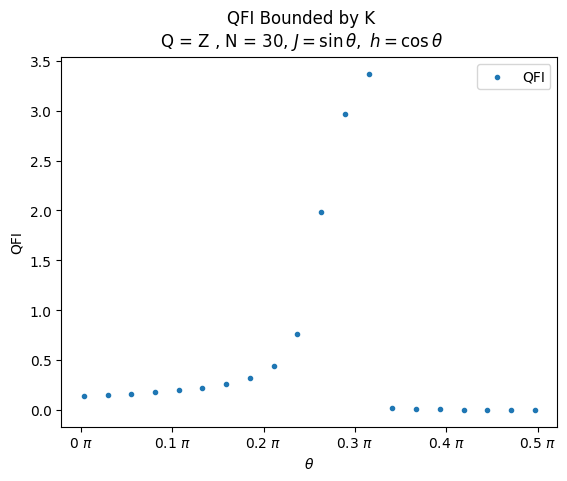

In [7]:
L = 30
chi_max = 20
op = 'Sigmax'
num_points = 20

dmrg_params = {
        'mixer': True,  # setting this to True helps to escape local minima
        'max_E_err': 1.e-10,
        'trunc_params': {
            'chi_max': 20,
            'svd_min': 1.e-10,
        },
        'combine': True
    }

theta_range = np.linspace(.01, np.pi/2- .01, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI_lst =[]
for theta in theta_range:
    J, g = np.sin(theta), np.cos(theta)

    model_params = {
    'J':  J , 'g':  g,  # critical
    'L': L,
    'bc_MPS': 'finite',
    'conserve' : None}

    M = TFIChain(model_params)
    psi = MPS.from_lat_product_state(M.lat, [['up', 'down']], allow_incommensurate= True)
    
    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_params)
    E, psi = eng.run() # the main work; modifies psi in place
    
    
    #Generate QFI
    QFI_lst += [QFI(psi, op)] #[qfi3]

#ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, QFI_lst, marker = '.', label = "QFI", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = Z , N = " + str(L) + ", $J = \\sin\\theta,~h = \\cos\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

In [33]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_L50_Ztot_QFI_Bound.png")